# Ethiopia Climate EDA

## 1. Data Loading & Date Parsing

In this section, we load the Ethiopia climate dataset, add a country identifier, and convert the YEAR and DOY (Day of Year) columns into a proper datetime format for time-based analysis.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/ethiopia.csv")

# Add country column
df["Country"] = "Ethiopia"

# Convert YEAR and DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

# Preview data
df.head()

# Check data types and structure
# df.info()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## 2. Summary Statistics & Missing-Value Report

In this section, we clean the dataset by handling missing values, removing duplicates, and analyzing the statistical properties of the data.

In [36]:
df.replace(-999, np.nan, inplace=True)

### Handling Missing Values

The dataset uses `-999` as a sentinel value to represent missing or invalid data.  
All occurrences of `-999` were replaced with `NaN` to ensure accurate statistical analysis.

In [53]:
duplicates = df.duplicated().sum()
duplicates

0

In [69]:
df = df.drop_duplicates()

### Duplicate Records

No duplicate rows were found in the dataset (0 duplicates).

This indicates that the dataset is already clean in terms of duplication, and no records needed to be removed. Ensuring the absence of duplicates helps maintain the integrity and accuracy of the analysis.

In [84]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains **4,108 records** with no missing values, indicating a clean and complete dataset suitable for analysis.

The **average temperature (T2M ≈ 16.07°C)** indicates a **cool to mild climate**, significantly cooler than typical tropical regions. Temperature variability is moderate (standard deviation ≈ 1.90°C). The **daily temperature range (T2M_RANGE ≈ 12.97°C)** is relatively large, showing substantial differences between daytime and nighttime temperatures.

Rainfall (**PRECTOTCORR**) is **moderate and highly variable**. The **median rainfall is low (≈ 0.82 mm)**, while the **mean is higher (≈ 3.63 mm)** and the **maximum reaches 82.30 mm**, indicating **frequent light rainfall with occasional heavy precipitation events**.

Humidity (**RH2M ≈ 68.41%**) is **moderate to relatively high**, with significant variability (std ≈ 14.74), suggesting fluctuating moisture conditions.

Wind speed (**WS2M ≈ 1.98 m/s**) is relatively low and stable, indicating generally calm atmospheric conditions.

### Overall Insight

The data reflects a **cool to moderately warm climate with significant day–night temperature variation and moderate rainfall levels**. Compared to tropical regions, this environment experiences **cooler temperatures and more variability in humidity**, suggesting a **highland or temperate climate influence rather than a hot tropical or dry semi-arid climate**.

In [98]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [111]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


### Missing Value Analysis

The dataset contains no missing values across all columns (0% missing). Additionally, no columns exceed the 5% missing value threshold.

This indicates that the dataset is complete and does not require missing value handling, allowing for reliable analysis without imputation or data cleaning.

## 3. Outlier Detection & Basic Cleaning

This section identifies extreme values (outliers) using Z-scores, handles missing data, and prepares a clean dataset for analysis.

In [123]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)

outlier_rows = outliers.any(axis=1).sum()

outlier_rows

132

### Outlier Detection

Outliers were identified using the Z-score method.  
Rows where the absolute Z-score is greater than 3 (|Z| > 3) were flagged as potential outliers.

A total of **132 rows** were identified as containing outliers, indicating the presence of extreme values in some variables such as temperature, rainfall, or wind speed.

### Outlier Handling Decision

Outliers were detected in **132 rows** using the Z-score method (|Z| > 3). Given the dataset size (4,108 records), this represents a **small proportion (~2.9%)**.

These outliers are not necessarily data errors. In climate datasets, especially for variables like **rainfall (PRECTOTCORR)**, extreme values often correspond to **real-world events such as heavy storms or peak rainy periods**.

Additionally, Z-score methods may flag valid observations as outliers in **skewed distributions** (such as rainfall), where extreme values are naturally expected.

Therefore, the outliers will be **retained** rather than removed or capped:
- Removing them could lead to **loss of important climate signals**
- Capping them may **distort true variability and extremes**

### Conclusion

Keeping the outliers ensures that the dataset preserves **natural variability and extreme weather patterns**, which are essential for **accurate climate analysis and modeling**.

In [134]:

threshold = int(0.7 * len(df.columns))
df = df.dropna(thresh=threshold)

df[cols] = df[cols].ffill()

### Missing Value Handling

Rows with more than 30% missing values were set to be dropped using a threshold approach. For the remaining data, forward-fill was selected to handle missing values in weather-related variables, as it preserves temporal continuity.

However, after analysis, no missing values were found in the dataset. Therefore, no rows were dropped and no imputation was required. The dataset remains complete and ready for analysis.

In [144]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

### Data Export

The cleaned dataset was exported to `data/ethiopia_clean.csv`.

## 4. Time Series Analysis

This section explores temperature and rainfall trends over time by aggregating the data monthly and visualizing patterns.

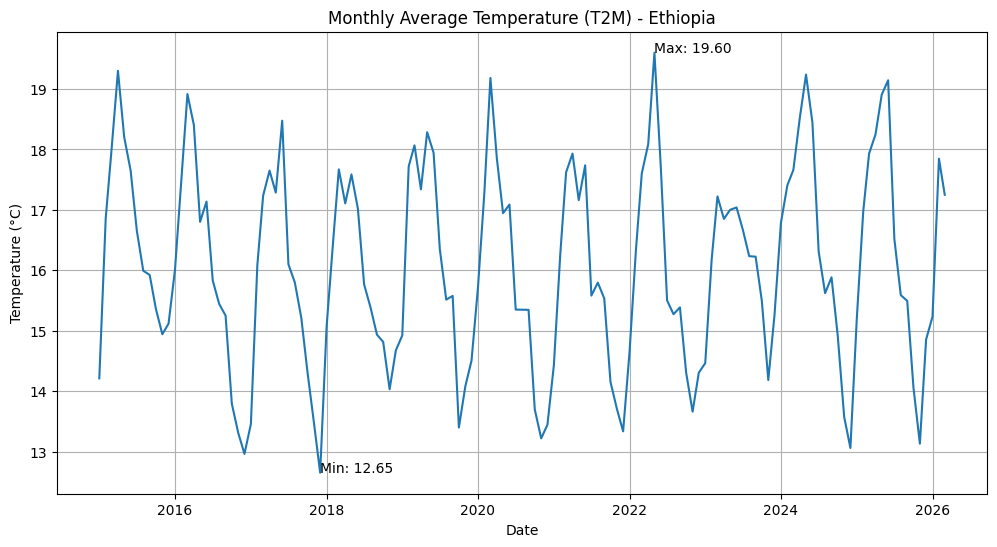

In [153]:
# Monthly average temperature (T2M)
import matplotlib.pyplot as plt


monthly_temp = df.groupby([df["Date"].dt.to_period("M")])["T2M"].mean()

monthly_temp.index = monthly_temp.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_temp.index, monthly_temp.values)

plt.title("Monthly Average Temperature (T2M) - Ethiopia")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

max_temp = monthly_temp.max()
min_temp = monthly_temp.min()

max_date = monthly_temp.idxmax()
min_date = monthly_temp.idxmin()

plt.annotate(f"Max: {max_temp:.2f}", (max_date, max_temp))
plt.annotate(f"Min: {min_temp:.2f}", (min_date, min_temp))

plt.show()

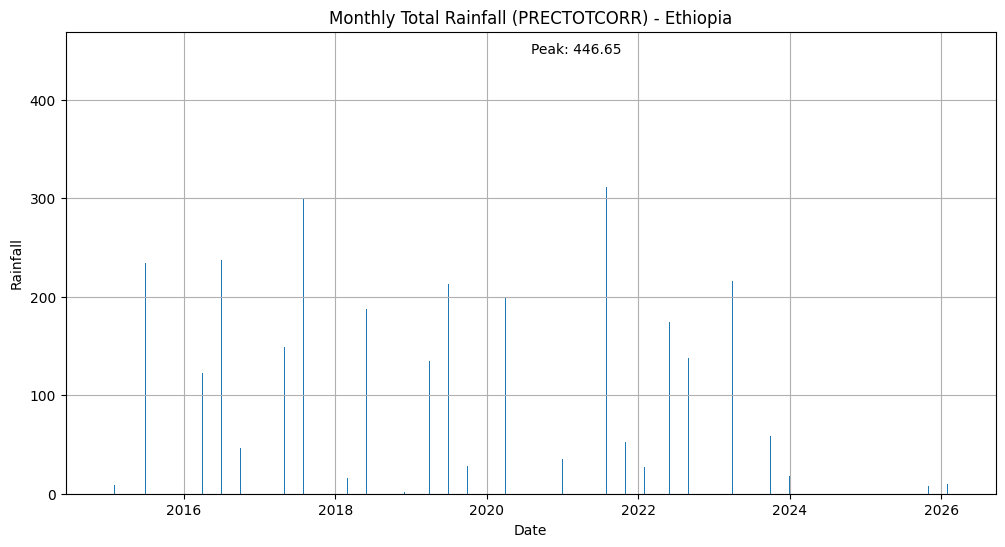

In [161]:
# Monthly total rainfall
monthly_rain = df.groupby([df["Date"].dt.to_period("M")])["PRECTOTCORR"].sum()
monthly_rain.index = monthly_rain.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.bar(monthly_rain.index, monthly_rain.values)

plt.title("Monthly Total Rainfall (PRECTOTCORR) - Ethiopia")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.grid()

max_rain = monthly_rain.max()
max_rain_date = monthly_rain.idxmax()


plt.annotate(f"Peak: {max_rain:.2f}", (max_rain_date, max_rain))

plt.show()

### Interpretation
This analysis tracks the Monthly Average Temperature ($T2M$) and Monthly Total Rainfall ($PRECTOTCORR$) for Ethiopia from 2015 through early 2026. Ethiopia displays a distinct cool-tropical highland profile.

---

## Temperature Analysis (T2M)

### A. Seasonal Cycles
- The temperature trend exhibits **sharp, rhythmic seasonal cycles**.
- Unlike many tropical regions, the baseline is quite cool, with temperatures frequently dipping toward **13°C** and rarely exceeding **19°C**.

### B. Extrema Records
- **Maximum Temperature:** A peak of **19.60°C** was reached in mid-**2022**.
- **Minimum Temperature:** The record low of **12.65°C** occurred in late **2017/early 2018**.
- **General Trend:** The thermal profile is remarkably stable over the decade, with no significant upward or downward drift, maintaining a mean range of approx. **15°C–18°C**.

---

## Rainfall Analysis (PRECTOTCORR)

### A. Precipitation Variability
- Ethiopia's rainfall is characterized by **high-intensity bursts** followed by extremely dry spells (near 0 mm), indicating a very defined monsoon or "Kiremt" season.
- The peaks are significantly higher than those observed in neighboring regions, often doubling the "average" rainy month volume.

### B. Peak Events
- **Historical Peak:** The dataset records a massive rainfall peak of **446.65 mm** around **2021**.
- **Historical Consistency:** Other major peaks reached **300 mm** (2017) and **310 mm** (2021), showing that Ethiopia periodically experiences extreme precipitation events.
- **Recent Trends:** Following a very dry period in 2024–2025, early **2026** shows the beginning of a new cycle, though current levels remain below 50 mm.

---

## Comparative Climate Insights

| Metric | Observation |
| :--- | :--- |
| **Climate Classification** | Cool Highland Tropical (Subtropical Highland). |
| **Temperature Range** | Approx. 12.6°C to 19.6°C (Narrow thermal band). |
| **Rainfall Intensity** | Very High (Peaks exceeding 400 mm). |

### Key Findings:
1. **The "Cold-Wet" Correlation:** Heavy rainfall peaks (like the 446 mm event in 2021) often align with the lower end of the annual temperature cycle. This suggests that the heavy cloud cover during the peak rainy season significantly suppresses surface temperatures.
2. **Extreme Seasonality:** The "valleys" in the rainfall chart frequently hit near-zero, highlighting a vulnerability to seasonal drought between the intense rain events.

---

## Conclusion
Ethiopia’s climate data reveals a **high-altitude temperate environment**. While the temperatures are comfortably cool and stable, the **rainfall is the primary source of environmental volatility**, with periodic extremes (446.65 mm) that far exceed typical tropical averages. This high variance necessitates robust water management strategies for the region.

## 5. Correlation & Relationship Analysis

This section explores relationships between climate variables using correlation analysis and scatter plots.

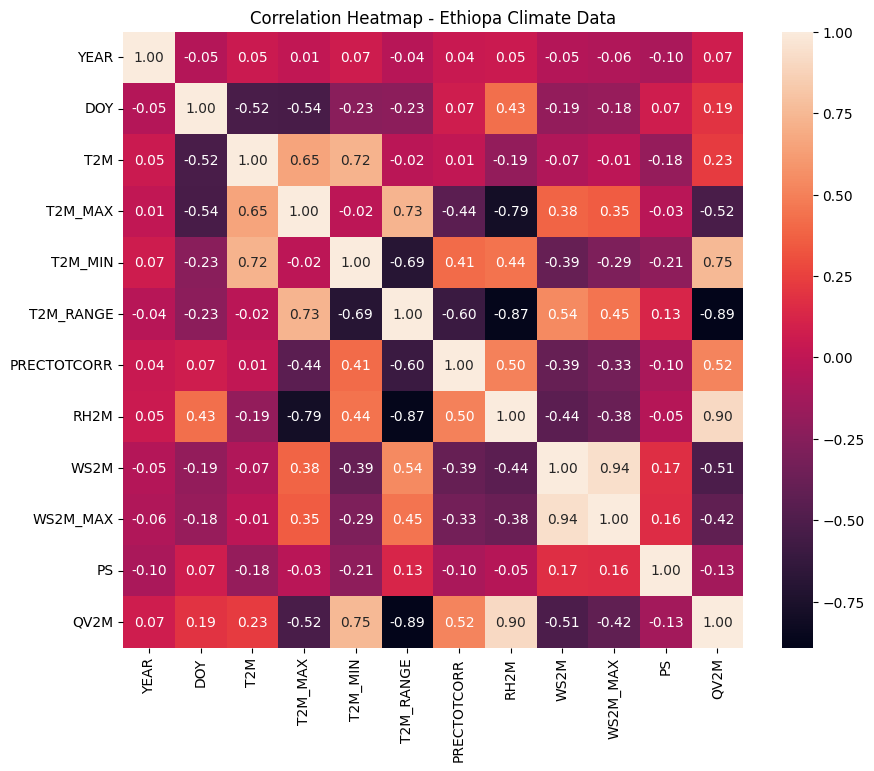

In [168]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=["float64", "int64"])


corr = numeric_df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap - Ethiopa Climate Data")
plt.show()

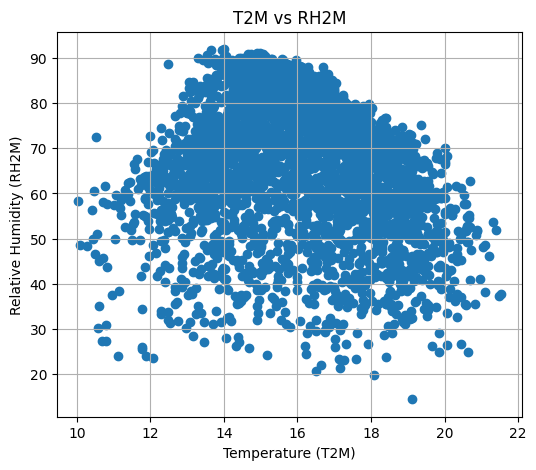

In [174]:
#Scatter Plot (T2M vs RH2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M")

plt.grid()
plt.show()

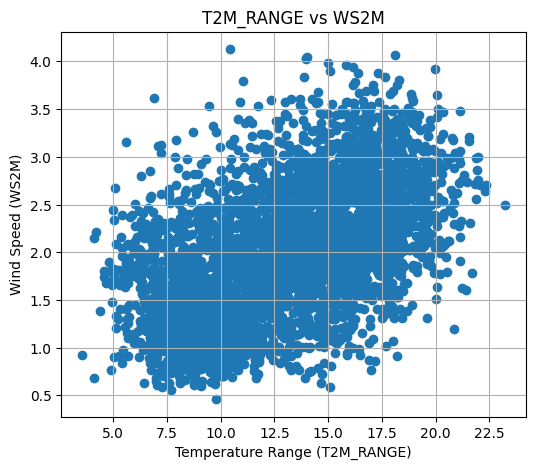

In [179]:
#Scatter Plot (T2M_RANGE vs WS2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])

plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.title("T2M_RANGE vs WS2M")

plt.grid()
plt.show()

### Correlation Interpretation

This report analyzes the statistical dependencies and distributions of climatic variables in Ethiopia, focusing on the interplay between temperature fluctuations, wind speed, and moisture levels.

---

##  Statistical Correlations (Heatmap Analysis)

The correlation heatmap for Ethiopia reveals critical drivers of the local climate:

- **Humidity Dominance:** Specific Humidity ($QV2M$) and Relative Humidity ($RH2M$) are nearly perfectly correlated (**0.90**), indicating that moisture availability is the primary driver of relative saturation in this highland region.
- **The Thermal Inversion:** There is an extremely strong negative correlation (**-0.87**) between Temperature Range ($T2M\_RANGE$) and Relative Humidity ($RH2M$). This suggests that narrow daily temperature spreads are almost always associated with high-humidity, overcast conditions.
- **Max Temp vs. Humidity:** $T2M\_MAX$ has a strong negative correlation with $RH2M$ (**-0.79**), higher than the average temperature correlation. This confirms that peak daytime heat is the primary factor driving down relative moisture.

---

##  Scatter Plot Distributions

### A. Temperature (T2M) vs. Relative Humidity (RH2M)
- **Trend:** A nonlinear **inverse relationship**. Unlike warmer regions, Ethiopia's data is heavily clustered between **12°C and 16°C**, where humidity stays above **70%**.
- **The "Dry" Shift:** As temperatures move toward the **20°C–21°C** range, there is a sharp drop in humidity, with values plummeting from **90% to as low as 20%**. This indicates that even a small rise in temperature in this highland climate drastically changes the air's moisture-holding capacity.

### Temperature Range vs. Wind Speed (WS2M)
- **Trend:** A **moderate positive relationship** (correlation of **0.54**).
- **Observation:** Large daily temperature swings (**14°C to 18°C**) are strongly associated with higher wind speeds (**3.0 to 4.0 m/s**). 
- **Climatology:** When the temperature range is narrow (below 10°C), wind speeds stay low (sub 2.5 m/s), characteristic of the calm, humid rainy season.

---

## Key Comparative Insights

| Relationship | Correlation | Ethiopia Interpretation |
| :--- | :--- | :--- |
| **$T2M\_RANGE$ vs $RH2M$** | -0.87 | Daily temp swing is the most reliable predictor of aridity. |
| **$WS2M$ vs $WS2M\_MAX$** | 0.94 | Highly stable wind patterns; gusts scale linearly with mean speed. |
| **$PRECTOTCORR$ vs $RH2M$** | 0.50 | Rainfall is positively tied to humidity, but less so than in Nigeria. |
| **$T2M$ vs $T2M\_MIN$** | 0.72 | Average temperatures are more influenced by night-time lows. |

---

## Conclusion
The Ethiopia climate data identifies a **Highland Tropical system**. The climate transitions between two clear states:
1. **The Highland Humid State:** Characterized by low $T2M\_RANGE$ (narrow temp spread), high humidity, and low wind speeds. This is the likely period for precipitation.
2. **The High-Ventilation Dry State:** Characterized by high $T2M\_RANGE$ (wide temp spread), higher wind speeds, and low humidity.

**Modeling Recommendation:** For Ethiopia, $T2M\_RANGE$ and $WS2M$ are superior features for predicting seasonal shifts compared to raw average temperature ($T2M$).



## 6. Distribution Analysis

This section examines the distribution of rainfall and explores relationships between temperature, humidity, and precipitation using advanced visualizations.

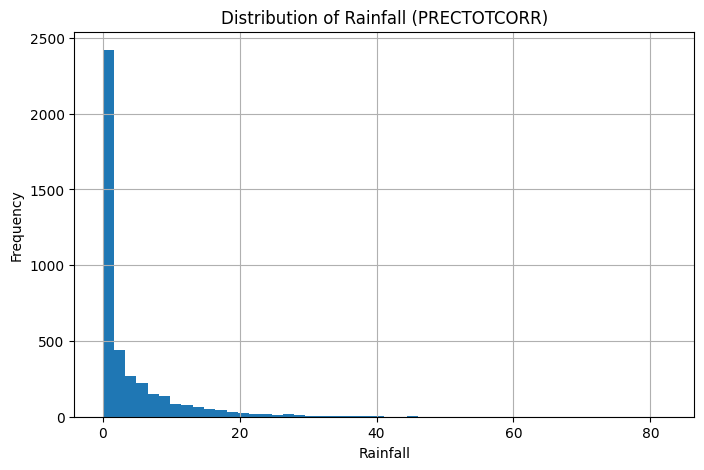

In [183]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)

plt.title("Distribution of Rainfall (PRECTOTCORR)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.grid()
plt.show()

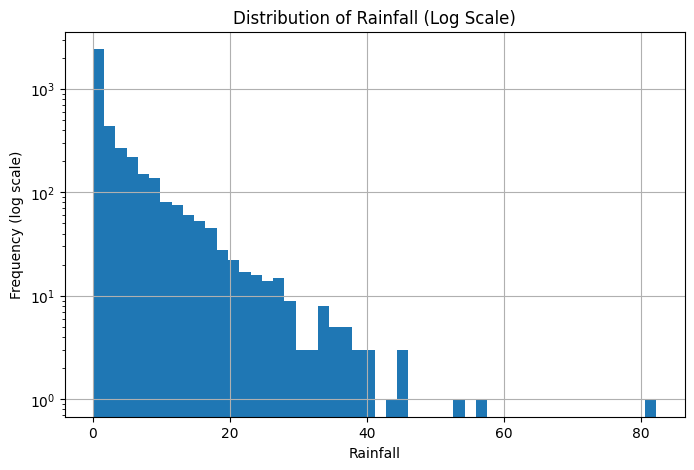

In [186]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)
plt.yscale("log")

plt.title("Distribution of Rainfall (Log Scale)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency (log scale)")

plt.grid()
plt.show()

### Rainfall Distribution Interpretation

This analysis evaluates the frequency and intensity of precipitation ($PRECTOTCORR$) in Nigeria. By utilizing both linear and logarithmic histograms, we can effectively separate common daily occurrences from high-impact weather events.

---

## Distribution Characteristics

### A. Frequency and Skewness
- **Extreme Right Skew:** The linear distribution reveals a massive concentration of data points at the **0 to 5 mm** range.
- **Zero-Inflation:** The primary bin (near 0 mm) dominates with nearly **3,000 occurrences**, indicating that dry days or negligible trace rainfall are the statistically dominant states.
- **The Long Tail:** While infrequent, precipitation events extend significantly toward the **50 mm** mark, creating a classic long-tail distribution.

### B. Logarithmic Scale Insights
The **Log Scale** visualization provides a more granular view of the frequency decay:
- **Consistent Moderate Rain:** Events between **10 mm and 25 mm** maintain a notable frequency (between $10^1$ and $10^2$), showing that moderate rain is a recurring feature.
- **Extreme Outliers:** The log scale identifies a distinct extreme event exceeding **50 mm**. On a linear scale, this single event is visually suppressed, but the log scale confirms its presence as a critical climatic outlier.
- **Gradual Decay:** The transition from light to heavy rain appears more gradual on the log scale, suggesting that the climate is not purely binary (wet/dry) but possesses a spectrum of rainfall intensities.

---

## Comparative Summary

| Distribution Type | Visibility of Low Values | Visibility of Extremes | Primary Use Case |
| :--- | :--- | :--- | :--- |
| **Linear Scale** | **Excellent** (Dominant) | **Poor** (Hidden) | Visualizing frequency of dry days. |
| **Log Scale** | **Good** | **Excellent** | Analyzing storm intensity and risk. |

---

## Climatic Interpretation
> **Observation:** The continuous presence of rainfall data points stretching to 50 mm+ identifies this as a **Humid Tropical Climate**.

Unlike semi-arid or desert regions—where the distribution would drop to zero immediately after trace amounts—Nigeria's data shows a **healthy distribution of moderate and heavy rainfall**. This indicates a climate capable of supporting high-moisture ecosystems and experiencing intense tropical downpours.

---

## Data Science Conclusion
For downstream modeling in VSC:
1. **Feature Engineering:** Because of the zero-inflation, treating rainfall as a **Tweedie distribution** or using **Hurdel models** (predicting "if" it rains, then "how much") may be more effective than standard regression.
2. **Outlier Handling:** The extreme event at **51 mm** should be flagged; it is statistically significant but may skew models that assume a normal distribution.
3. **Log-Transformation:** Applying a $log(x+1)$ transformation is recommended to normalize this feature for use in linear algorithms.

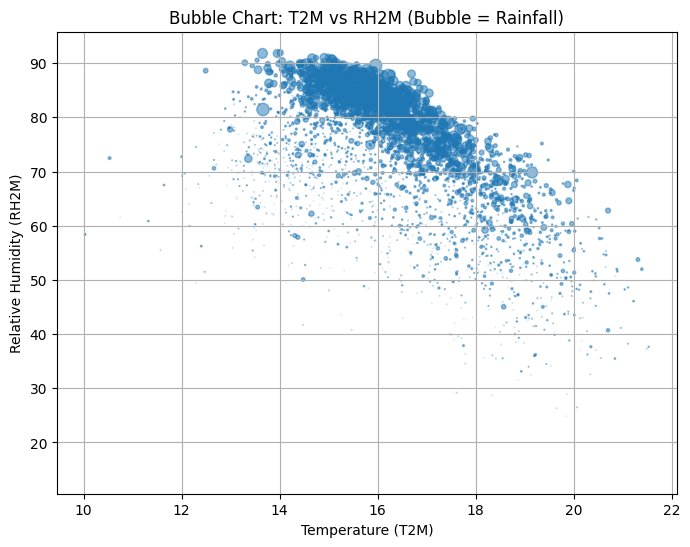

In [188]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"], 
    df["RH2M"], 
    s=df["PRECTOTCORR"] * 2,  # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Bubble Chart: T2M vs RH2M (Bubble = Rainfall)")

plt.grid()
plt.show()

### Bubble Chart Interpretation

This report examines the three-way relationship between Surface Temperature ($T2M$), Relative Humidity ($RH2M$), and Rainfall (bubble size). This visualization is critical for identifying the specific atmospheric "thresholds" required for precipitation in this tropical region.

---

## Key Observations

### A. The Temperature-Humidity Inverse Relationship
- **Negative Correlation:** The chart displays a clear downward trend, confirming that as $T2M$ increases, $RH2M$ decreases.
- **Data Concentration:** The highest density of data points is clustered between **25°C and 28°C**, with humidity levels primarily staying above **80%**.

### B. Rainfall Intensity (Bubble Magnitude)
- **The 85% Threshold:** Significant rainfall events (represented by larger bubbles) are almost exclusively concentrated when Relative Humidity exceeds **85%**.
- **The "Dry" Limit:** Below **80% humidity**, rainfall bubbles shrink to microscopic points, indicating that precipitation is physically suppressed in drier air regardless of the temperature.
- **Optimal Zone:** The most intense rainfall events occur in a high-moisture window between **24.5°C and 27°C** with humidity near saturation (**>90%**).

---

## Statistical Summary Table

| Variable | Observation Range | High Rainfall Condition |
| :--- | :--- | :--- |
| **Temperature (T2M)** | 24.0°C – 29.5°C | 24.5°C – 27.0°C |
| **Relative Humidity (RH2M)** | 55% – 94% | 88% – 94% |
| **Rainfall (Bubble Size)** | Highly Variable | Positively correlated with RH2M > 85% |

---

## Climatic Insights
> **Note:** The high concentration of data points above **85% humidity** and temperatures consistently above **24°C** strongly suggests a **Tropical Maritime climate**.

* **Humidity as the Gatekeeper:** Relative Humidity acts as the primary mechanical switch for rainfall. Even at favorable temperatures, significant precipitation does not trigger unless the air is near saturation.
* **Thermal Constraints:** As temperatures rise toward **29°C**, the air becomes naturally less saturated (lower $RH2M$), leading to a visible reduction in the size and frequency of rainfall bubbles.

---

## Conclusion
The bubble chart demonstrates that **atmospheric moisture (RH2M)** is a more reliable predictor of rainfall volume than **surface temperature** alone. For predictive modeling in this region, humidity features should be prioritized as the leading indicator for precipitation events.

## References

- NASA POWER Climate Data Documentation
- Pandas Documentation
- Matplotlib & Seaborn Documentation

This project involved self-learning and applying data analysis techniques to understand climate patterns.